<a href="https://colab.research.google.com/github/shreyas284-crtl/Data-Science-Internship/blob/main/SHREYAS_BS_DSTASKS_day_21_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Null values per column:
 StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

Duplicate rows: 0

Rows before cleaning: 1000
Rows after cleaning: 645


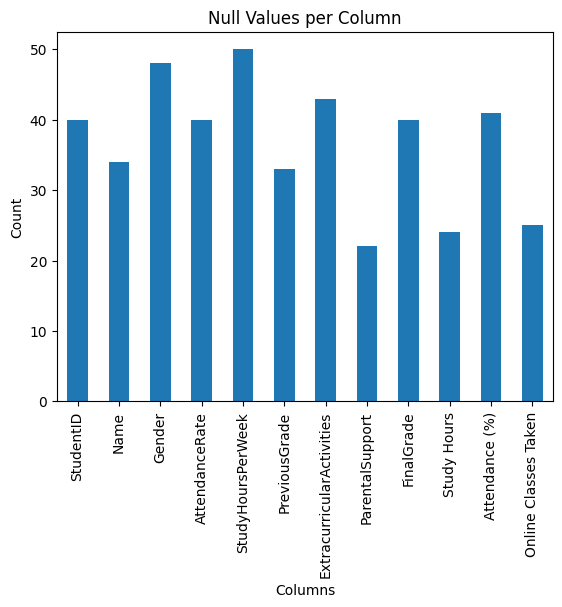

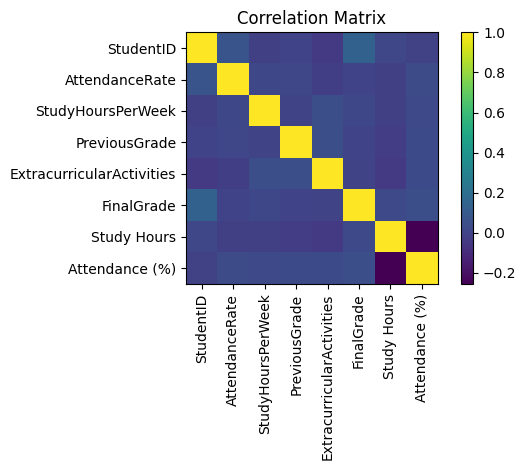


Model MSE: 91.65212951073967

Prediction Table (first 10 rows):
   Actual_FinalGrade  Predicted_FinalGrade
0               87.0             79.353344
1               68.0             78.044193
2               90.0             80.262414
3               90.0             80.554007
4               85.0             80.610737
5               62.0             78.599325
6               87.0             80.761153
7               78.0             80.300442
8               85.0             78.235673
9               87.0             82.037034


In [ ]:
#class 21

#clear the data and see if you have any null or duplicate values

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("student_performance_updated_1000.csv")

print("Null values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df_clean = df.drop_duplicates().dropna()

print("\nRows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

plt.figure()
df.isnull().sum().plot(kind='bar')
plt.title("Null Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

numeric_df = df_clean.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

if "FinalGrade" in numeric_df.columns:
    X = numeric_df.drop("FinalGrade", axis=1, errors="ignore")
    y = numeric_df["FinalGrade"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)

    results = pd.DataFrame({
        "Actual_FinalGrade": y_test.values,
        "Predicted_FinalGrade": preds
    })

    print("\nModel MSE:", mse)
    print("\nPrediction Table (first 10 rows):")
    print(results.head(10))



Null values per column:
 StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

Duplicate rows: 0

Rows after cleaning: 1000


/tmp/ipython-input-354/2737984570.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-354/2737984570.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

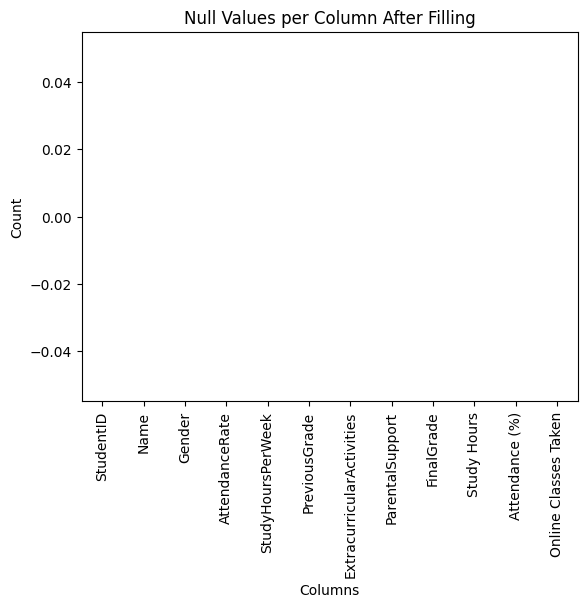

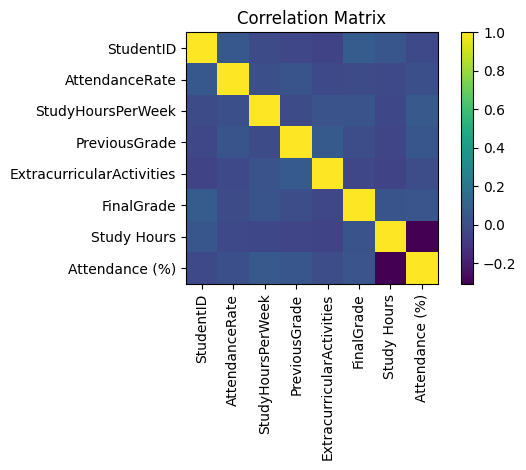


Model MSE: 88.69439514691774

Prediction Table (first 10 rows):
   Actual_FinalGrade  Predicted_FinalGrade
0               72.0             79.608087
1               62.0             79.243024
2               62.0             80.642529
3               80.0             78.799414
4               85.0             78.799796
5               78.0             80.149761
6               87.0             80.935875
7               87.0             78.986079
8               68.0             80.379718
9               80.0             79.953812


In [ ]:
# with median and mode

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("student_performance_updated_1000.csv")

print("Null values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nRows after cleaning:", len(df))

plt.figure()
df.isnull().sum().plot(kind='bar')
plt.title("Null Values per Column After Filling")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

if "FinalGrade" in numeric_df.columns:
    X = numeric_df.drop("FinalGrade", axis=1, errors="ignore")
    y = numeric_df["FinalGrade"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)

    results = pd.DataFrame({
        "Actual_FinalGrade": y_test.values,
        "Predicted_FinalGrade": preds
    })

    print("\nModel MSE:", mse)
    print("\nPrediction Table (first 10 rows):")
    print(results.head(10))

In [ ]:
 #filling the missing vales

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("student_performance_updated_1000.csv")

df = df.drop_duplicates()

num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(exclude=["int64","float64"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

numeric_df = df.select_dtypes(include="number")

if "FinalGrade" in numeric_df.columns:
    X = numeric_df.drop("FinalGrade", axis=1)
    y = numeric_df["FinalGrade"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression().fit(X_train, y_train)
    preds = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, preds))
    print(pd.DataFrame({"Actual": y_test.values, "Predicted": preds}).head())

MSE: 88.69439514691774
   Actual  Predicted
0    72.0  79.608087
1    62.0  79.243024
2    62.0  80.642529
3    80.0  78.799414
4    85.0  78.799796


/tmp/ipython-input-354/1134118296.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [ ]:
import pandas as pd

df = pd.read_csv("student_performance_updated_1000.csv")

numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Mean values:\n")
print(numeric_df.mean())

print("\nMedian values:\n")
print(numeric_df.median())

Mean values:

StudentID                    5416.019792
AttendanceRate                 85.510417
StudyHoursPerWeek              17.630526
PreviousGrade                  77.598759
ExtracurricularActivities       1.520376
FinalGrade                     80.030208
Study Hours                     2.406967
Attendance (%)                 77.248175
dtype: float64

Median values:

StudentID                    5396.5
AttendanceRate                 88.0
StudyHoursPerWeek              18.0
PreviousGrade                  78.0
ExtracurricularActivities       1.0
FinalGrade                     80.0
Study Hours                     2.5
Attendance (%)                 76.0
dtype: float64


In [ ]:
# gender -> Binary Encoding

df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

df["Online Classes Taken"] = pd.to_numeric(
    df["Online Classes Taken"], errors="coerce"
).fillna(0).astype(int)

df["ParentalSupport"] = df["ParentalSupport"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2,
})

print(df.head())

   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John     NaN            85.0               15.0   
1        2.0    Sarah     NaN            90.0               20.0   
2        3.0     Alex     NaN            78.0               10.0   
3        4.0  Michael     NaN            92.0               25.0   
4        5.0     Emma     NaN             NaN               18.0   

   PreviousGrade  ExtracurricularActivities  ParentalSupport  FinalGrade  \
0           78.0                        1.0              NaN        80.0   
1           85.0                        2.0              NaN        87.0   
2           65.0                        0.0              NaN        68.0   
3           90.0                        3.0              NaN        92.0   
4           82.0                        2.0              NaN        85.0   

   Study Hours  Attendance (%)  Online Classes Taken  
0          4.8            59.0                     0  
1          2.2          

In [ ]:
df["FinalGrade"] = df["FinalGrade"].fillna(df["FinalGrade"].median())

df["PerformanceLevel"] = pd.cut(
    df["FinalGrade"],
    bins=[0, 60, 80, 100],
    labels=[0, 1, 2]
).astype(int)

print(df["PerformanceLevel"].head())

0    1
1    2
2    1
3    2
4    2
Name: PerformanceLevel, dtype: int64


In [ ]:
def perf_level(x):
    if pd.isna(x):
        return 1
    elif x < 60:
        return 0
    elif x < 80:
        return 1
    else:
        return 2

df["PerformanceLevel"] = df["FinalGrade"].apply(perf_level)
df = df.drop(columns=["FinalGrade"])

print(df.head())

   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John     NaN            85.0               15.0   
1        2.0    Sarah     NaN            90.0               20.0   
2        3.0     Alex     NaN            78.0               10.0   
3        4.0  Michael     NaN            92.0               25.0   
4        5.0     Emma     NaN             NaN               18.0   

   PreviousGrade  ExtracurricularActivities  ParentalSupport  Study Hours  \
0           78.0                        1.0              NaN          4.8   
1           85.0                        2.0              NaN          2.2   
2           65.0                        0.0              NaN          4.6   
3           90.0                        3.0              NaN          2.9   
4           82.0                        2.0              NaN          4.1   

   Attendance (%)  Online Classes Taken  PerformanceLevel  
0            59.0                     0                 2  
1       

In [ ]:
print(df.isnull().sum())

StudentID                      40
Name                           34
Gender                       1000
AttendanceRate                 40
StudyHoursPerWeek              50
PreviousGrade                  33
ExtracurricularActivities      43
ParentalSupport              1000
Study Hours                    24
Attendance (%)                 41
Online Classes Taken            0
PerformanceLevel                0
dtype: int64


Missing values column-wise:
 StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

Duplicate rows: 0


/tmp/ipython-input-354/107633789.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


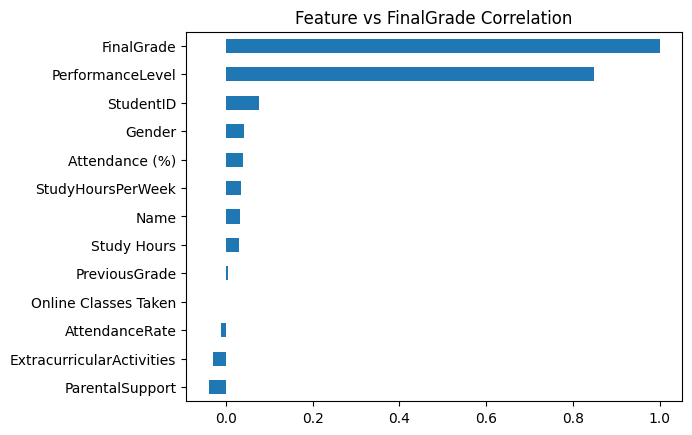


Regression Results
LinearRegression MSE: 90.7515112864972
   Actual  Predicted
0    72.0  81.845883
1    62.0  79.366092
2    62.0  82.375819
3    80.0  78.229350
4    85.0  80.233593 

DecisionTree MSE: 151.8
   Actual  Predicted
0    72.0       88.0
1    62.0       72.0
2    62.0       80.0
3    80.0       87.0
4    85.0       62.0 

RandomForest MSE: 92.69506250000002
   Actual  Predicted
0    72.0      79.55
1    62.0      81.46
2    62.0      81.50
3    80.0      78.96
4    85.0      78.27 


Classification Results
LogisticRegression Accuracy: 0.615
              precision    recall  f1-score   support

           1       0.47      0.11      0.17        76
           2       0.63      0.93      0.75       124

    accuracy                           0.61       200
   macro avg       0.55      0.52      0.46       200
weighted avg       0.57      0.61      0.53       200

DecisionTreeClassifier Accuracy: 0.555
              precision    recall  f1-score   support

           1     

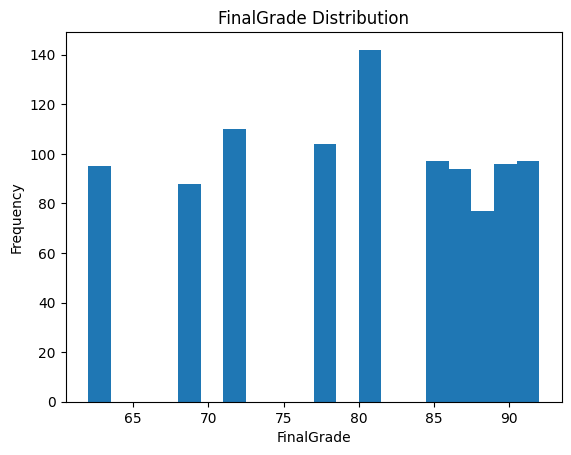


Final cleaned dataset preview:
   StudentID  Name  Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
0        1.0   427       0            85.0               15.0           78.0   
1        2.0   826       1            90.0               20.0           85.0   
2        3.0    12       0            78.0               10.0           65.0   
3        4.0   646       0            92.0               25.0           90.0   
4        5.0   299       1            88.0               18.0           82.0   

   ExtracurricularActivities  ParentalSupport  FinalGrade  Study Hours  \
0                        1.0                2        80.0          4.8   
1                        2.0                1        87.0          2.2   
2                        0.0                0        68.0          4.6   
3                        3.0                2        92.0          2.9   
4                        2.0                1        85.0          4.1   

   Attendance (%)  Online Classes Taken  P

In [ ]:
# Training Testing and Splitting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

df = pd.read_csv("student_performance_updated_1000.csv")

print("Missing values column-wise:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(exclude=["int64", "float64"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["ParentalSupport"] = df["ParentalSupport"].map({"Low": 0, "Medium": 1, "High": 2})
df["Online Classes Taken"] = pd.to_numeric(df["Online Classes Taken"], errors="coerce").fillna(0).astype(int)

def perf_level(x):
    if x < 60:
        return 0
    elif x < 80:
        return 1
    else:
        return 2

df["PerformanceLevel"] = df["FinalGrade"].apply(perf_level)

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

numeric_df = df.select_dtypes(include="number")

plt.figure()
numeric_df.corr()["FinalGrade"].sort_values().plot(kind="barh")
plt.title("Feature vs FinalGrade Correlation")
plt.show()

X_reg = numeric_df.drop(["FinalGrade", "PerformanceLevel"], axis=1, errors="ignore")
y_reg = numeric_df["FinalGrade"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
Xr_train = scaler.fit_transform(Xr_train)
Xr_test = scaler.transform(Xr_test)

models_reg = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
}

print("\nRegression Results")
for name, model in models_reg.items():
    model.fit(Xr_train, yr_train)
    preds = model.predict(Xr_test)
    mse = mean_squared_error(yr_test, preds)
    print(name, "MSE:", mse)

    results = pd.DataFrame({"Actual": yr_test.values, "Predicted": preds})
    print(results.head(), "\n")

X_clf = numeric_df.drop(["PerformanceLevel", "FinalGrade"], axis=1, errors="ignore")
y_clf = numeric_df["PerformanceLevel"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

Xc_train = scaler.fit_transform(Xc_train)
Xc_test = scaler.transform(Xc_test)

models_clf = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42),
}

print("\nClassification Results")
for name, model in models_clf.items():
    model.fit(Xc_train, yc_train)
    preds = model.predict(Xc_test)
    acc = accuracy_score(yc_test, preds)
    print(name, "Accuracy:", acc)
    print(classification_report(yc_test, preds))

plt.figure()
plt.hist(df["FinalGrade"], bins=20)
plt.title("FinalGrade Distribution")
plt.xlabel("FinalGrade")
plt.ylabel("Frequency")
plt.show()

print("\nFinal cleaned dataset preview:")
print(df.head())

In [ ]:
#class 22